In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

import concurrent.futures


import numpy as np
import pandas as pd
import ast
import glob
import pickle
import dask
import os
import itertools

import pickle

#from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from statsmodels.regression.rolling import RollingOLS

from tqdm.notebook import tqdm

from multiprocessing import Pool, cpu_count
from joblib import Parallel, delayed
#from tqdm import tqdm
from collections import Counter
from functools import reduce


import dask
import dask.dataframe as dd
from dask.distributed import Client
from dask.diagnostics import ProgressBar

#client = Client(n_workers=20, memory_limit="10GB", interface='lo')
from concurrent.futures import ThreadPoolExecutor

import dask_ml.cluster as dask_cluster

from pprint import pprint
import os

pd.set_option('display.max_columns', None)

### Load Augmented DF Benchmark Dataset

In [2]:
augmented_df = dd.read_csv("../../data/augmented_us-counties_latest.csv", assume_missing=True).compute()
augmented_df["date"] = pd.to_datetime(augmented_df["date"])
augmented_df["fips"] = augmented_df["fips"].astype(int)
augmented_df["days_from_start"] = augmented_df["days_from_start"].astype(int)
augmented_df["log_rolled_cases"] = np.log(augmented_df["rolled_cases"] + 1.1)
df = augmented_df.copy()
window_sizes = [2,7,14]
fips_list = df["fips"].unique()

/home/zwang937/anaconda3/lib/python3.7/site-packages/pandas/core/arraylike.py:364: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


### Load Benchmark Data of $wsize \in \{2,3,4,\dotsc,13,14\}$

In [3]:
directory = "Fixed_Window_dfs"
file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(".csv")]
def read_csv(file_path):
    return pd.read_csv(file_path)
with tqdm(total=len(file_paths), desc="Processing") as pbar:
    beta_results = Parallel(n_jobs=-1)(delayed(read_csv)(file_path) for file_path in file_paths)

### Check for Duplicates

In [4]:
present_fips_wsize_dict = {}
for fname in file_paths:
    fips = int(float(fname.split("=")[1].split("_")[0]))
    window_size = int(float(fname.split("=")[2].split(".")[0]))
    if fips not in present_fips_wsize_dict.keys():
        present_fips_wsize_dict[fips] = Counter()
    if window_size in present_fips_wsize_dict[fips].keys():
        print("Duplicate detected fips={} window_size={}".format(fips, window_size))
        present_fips_wsize_dict[fips][window_size] += 1
    else:
        present_fips_wsize_dict[fips].update({window_size : 1})

### Remove fips with too few entries

In [5]:
sorted_beta_results = sorted(beta_results, key = lambda x: (x["fips"].unique()[0], x.columns[2] ))

beta_result_dict_wsize_fips = {}
for beta_df in tqdm(sorted_beta_results):
    fips = int(beta_df["fips"].unique()[0])
    window_size = int(beta_df.columns[2].split("=")[1])
    if fips not in beta_result_dict_wsize_fips.keys():
        beta_result_dict_wsize_fips[fips] = {window_size:beta_df}
    else:
        beta_result_dict_wsize_fips[fips][window_size] = beta_df
        

counter = 0
problematic_fips = {}
for fips in tqdm(beta_result_dict_wsize_fips.keys()):
    counter += 1
    expected_shape = list(beta_result_dict_wsize_fips[fips].items())[0][1].shape
    #print("fips={} has expected shape {}".format(fips, expected_shape))
    have_windows = set(beta_result_dict_wsize_fips[fips].keys())
    missing_window_sizes = set(window_sizes) - set(have_windows)
    if len(missing_window_sizes):
        print("fips={} has missing window_sizes of {}".format(fips, missing_window_sizes))
        problematic_fips[fips] = missing_window_sizes
    for window_size in beta_result_dict_wsize_fips[fips].keys():
        current_shape = beta_result_dict_wsize_fips[fips][window_size].shape
        if current_shape != expected_shape:
            print("fips={}, wsize={} has shape {}, differing from expected {}".format(fips, window_size, expected_shape, current_shape))
        
print(len(fips_list) - counter)


0


In [6]:
beta_result_dict_wsize_fips[1001]

{10:       fips  days_from_start  beta_wsize=10
 0     1001               69            NaN
 1     1001               70            NaN
 2     1001               71            NaN
 3     1001               72            NaN
 4     1001               73            NaN
 ...    ...              ...            ...
 1084  1001             1153      -0.045053
 1085  1001             1154      -0.049459
 1086  1001             1155      -0.053846
 1087  1001             1156      -0.057612
 1088  1001             1157      -0.058405
 
 [1089 rows x 3 columns],
 11:       fips  days_from_start  beta_wsize=11
 0     1001               69            NaN
 1     1001               70            NaN
 2     1001               71            NaN
 3     1001               72            NaN
 4     1001               73            NaN
 ...    ...              ...            ...
 1084  1001             1153      -0.042921
 1085  1001             1154      -0.047085
 1086  1001             1155      -0.051

### Merge Results

In [10]:
beta_result_dict = {window_size:[] for window_size in window_sizes}
for beta_df in tqdm(sorted_beta_results):
    fips = int(beta_df["fips"].unique()[0])
    window_size = int(beta_df.columns[2].split("=")[1])
    if fips not in problematic_fips.keys() and window_size in window_sizes:
        beta_result_dict[window_size].append(beta_df)

concatenated_beta_result_dict = {}
for window_size, beta_df_list in tqdm(beta_result_dict.items()):
    concatenated_beta_result_dict[window_size] = pd.concat(beta_df_list)
#updated_df.to_csv("TLGRF_w_Fixed_Windows.csv", index=False)

In [11]:
concatenated_beta_result_dict

{2:        fips  days_from_start  beta_wsize=2
 0      1001               69           NaN
 1      1001               70      0.128657
 2      1001               71      0.113975
 3      1001               72      0.069352
 4      1001               73      0.095767
 ...     ...              ...           ...
 1107  99999             1153     -0.033310
 1108  99999             1154     -0.047988
 1109  99999             1155     -0.066658
 1110  99999             1156     -0.024689
 1111  99999             1157     -0.030971
 
 [3390316 rows x 3 columns],
 7:        fips  days_from_start  beta_wsize=7
 0      1001               69           NaN
 1      1001               70           NaN
 2      1001               71           NaN
 3      1001               72           NaN
 4      1001               73           NaN
 ...     ...              ...           ...
 1107  99999             1153     -0.030987
 1108  99999             1154     -0.034865
 1109  99999             1155     -0.03

In [12]:
beta_df_big = pd.DataFrame()
#for window_size, fips_beta_df in tqdm(concatenated_beta_result_dict.items()):
#    if not beta_df_big.shape[0]:
#        beta_df_big = fips_beta_df.copy()
#        continue
#    beta_df_big = pd.merge(beta_df_big, fips_beta_df, on="fips", how="outer")

beta_df_big = reduce(lambda left, right: pd.merge(left, right, on=['fips','days_from_start'], how='outer'), concatenated_beta_result_dict.values())


updated_df = pd.merge(df, beta_df_big,on=['fips','days_from_start'], how="outer").sort_values(by=["fips", 'days_from_start'])


In [13]:
updated_df

,fips,date,county,state,cases,deaths,datetime,days_from_start,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,log_rolled_cases,beta_wsize=2,beta_wsize=7,beta_wsize=14
23,1001,2020-03-30,Autauga,Alabama,7.0,0.0,2020-03-30,69,5.142857,32.532237,-86.64644,594.443459,55200.0,23315.0,21115.0,8422.0,1065.0,29372.0,4204.0,8050.0,13369.0,10465.0,1586.0,13788.0,426.0,886.0,4279.0,299.0,1191.0,546.0,15.4,2.1,4.2,1.0,29372.0,2306.0,11.3,1.3,14.6,0.1,24.2,0.1,19.3,1.3,7.5,1.5,25.0,0.1,0.8,0.4,3.8,1.3,18.4,2.0,1.4,0.7,5.6,1.3,1.0,0.3,0.5401,0.2745,0.2860,0.4397,1.5403,0.3631,0.1850,0.7529,0.7905,0.3792,2.1076,0.5810,0.6336,0.5113,1.1449,0.5947,0.6017,0.7408,0.2964,0.4846,0.1525,2.2760,0.3741,7.0688,0.4354,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3875.0,7.1,0.9,37301.0,1.831438,NaN,NaN,NaN
120,1001,2020-03-31,Autauga,Alabama,7.0,0.0,2020-03-31,70,6.000000,32.532237,-86.64644,594.443459,55200.0,23315.0,21115.0,8422.0,1065.0,29372.0,4204.0,8050.0,13369.0,10465.0,1586.0,13788.0,426.0,886.0,4279.0,299.0,1191.0,546.0,15.4,2.1,4.2,1.0,29372.0,2306.0,11.3,1.3,14.6,0.1,24.2,0.1,19.3,1.3,7.5,1.5,25.0,0.1,0.8,0.4,3.8,1.3,18.4,2.0,1.4,0.7,5.6,1.3,1.0,0.3,0.5401,0.2745,0.2860,0.4397,1.5403,0.3631,0.1850,0.7529,0.7905,0.3792,2.1076,0.5810,0.6336,0.5113,1.1449,0.5947,0.6017,0.7408,0.2964,0.4846,0.1525,2.2760,0.3741,7.0688,0.4354,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3875.0,7.1,0.9,37301.0,1.960095,0.128657,NaN,NaN
154,1001,2020-04-01,Autauga,Alabama,10.0,0.0,2020-04-01,71,6.857143,32.532237,-86.64644,594.443459,55200.0,23315.0,21115.0,8422.0,1065.0,29372.0,4204.0,8050.0,13369.0,10465.0,1586.0,13788.0,426.0,886.0,4279.0,299.0,1191.0,546.0,15.4,2.1,4.2,1.0,29372.0,2306.0,11.3,1.3,14.6,0.1,24.2,0.1,19.3,1.3,7.5,1.5,25.0,0.1,0.8,0.4,3.8,1.3,18.4,2.0,1.4,0.7,5.6,1.3,1.0,0.3,0.5401,0.2745,0.2860,0.4397,1.5403,0.3631,0.1850,0.7529,0.7905,0.3792,2.1076,0.5810,0.6336,0.5113,1.1449,0.5947,0.6017,0.7408,0.2964,0.4846,0.1525,2.2760,0.3741,7.0688,0.4354,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3875.0,7.1,0.9,37301.0,2.074070,0.113975,NaN,NaN
585,1001,2020-04-02,Autauga,Alabama,10.0,0.0,2020-04-02,72,7.428571,32.532237,-86.64644,594.443459,55200.0,23315.0,21115.0,8422.0,1065.0,29372.0,4204.0,8050.0,13369.0,10465.0,1586.0,13788.0,426.0,886.0,4279.0,299.0,1191.0,546.0,15.4,2.1,4.2,1.0,29372.0,2306.0,11.3,1.3,14.6,0.1,24.2,0.1,19.3,1.3,7.5,1.5,25.0,0.1,0.8,0.4,3.8,1.3,18.4,2.0,1.4,0.7,5.6,1.3,1.0,0.3,0.5401,0.2745,0.2860,0.4397,1.5403,0.3631,0.1850,0.7529,0.7905,0.3792,2.1076,0.5810,0.6336,0.5113,1.1449,0.5947,0.6017,0.7408,0.2964,0.4846,0.1525,2.2760,0.3741,7.0688,0.4354,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3875.0,7.1,0.9,37301.0,2.143422,0.069352,NaN,NaN
55,1001,2020-04-03,Autauga,Alabama,12.0,0.0,2020-04-03,73,8.285714,32.532237,-86.64644,594.443459,55200.0,23315.0,21115.0,8422.0,1065.0,29372.0,4204.0,8050.0,13369.0,10465.0,1586.0,13788.0,426.0,886.0,4279.0,299.0,1191.0,546.0,15.4,2.1,4.2,1.0,29372.0,2306.0,11.3,1.3,14.6,0.1,24.2,0.1,19.3,1.3,7.5,1.5,25

In [20]:
filtered_updated_df = updated_df.dropna(subset=["beta_wsize=14"])
filtered_updated_df["shifted_log_rolled_cases"] = filtered_updated_df.groupby("fips")["log_rolled_cases"].shift(-7)
display(filtered_updated_df)

/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


,fips,date,county,state,cases,deaths,datetime,days_from_start,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,log_rolled_cases,beta_wsize=2,beta_wsize=7,beta_wsize=14,shifted_log_rolled_cases
534,1001,2020-04-12,Autauga,Alabama,19.0,1.0,2020-04-12,82,15.428571,32.532237,-86.64644,594.443459,55200.0,23315.0,21115.0,8422.0,1065.0,29372.0,4204.0,8050.0,13369.0,10465.0,1586.0,13788.0,426.0,886.0,4279.0,299.0,1191.0,546.0,15.4,2.1,4.2,1.0,29372.0,2306.0,11.3,1.3,14.6,0.1,24.2,0.1,19.3,1.3,7.5,1.5,25.0,0.1,0.8,0.4,3.8,1.3,18.4,2.0,1.4,0.7,5.6,1.3,1.0,0.3,0.5401,0.2745,0.2860,0.4397,1.5403,0.3631,0.1850,0.7529,0.7905,0.3792,2.1076,0.5810,0.6336,0.5113,1.1449,0.5947,0.6017,0.7408,0.2964,0.4846,0.1525,2.2760,0.3741,7.0688,0.4354,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3875.0,7.1,0.9,37301.0,2.805090,0.062409,0.055794,0.070954,3.095578
1087,1001,2020-04-13,Autauga,Alabama,19.0,1.0,2020-04-13,83,16.428571,32.532237,-86.64644,594.443459,55200.0,23315.0,21115.0,8422.0,1065.0,29372.0,4204.0,8050.0,13369.0,10465.0,1586.0,13788.0,426.0,886.0,4279.0,299.0,1191.0,546.0,15.4,2.1,4.2,1.0,29372.0,2306.0,11.3,1.3,14.6,0.1,24.2,0.1,19.3,1.3,7.5,1.5,25.0,0.1,0.8,0.4,3.8,1.3,18.4,2.0,1.4,0.7,5.6,1.3,1.0,0.3,0.5401,0.2745,0.2860,0.4397,1.5403,0.3631,0.1850,0.7529,0.7905,0.3792,2.1076,0.5810,0.6336,0.5113,1.1449,0.5947,0.6017,0.7408,0.2964,0.4846,0.1525,2.2760,0.3741,7.0688,0.4354,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3875.0,7.1,0.9,37301.0,2.863832,0.058742,0.058339,0.066433,3.114784
315,1001,2020-04-14,Autauga,Alabama,23.0,1.0,2020-04-14,84,18.000000,32.532237,-86.64644,594.443459,55200.0,23315.0,21115.0,8422.0,1065.0,29372.0,4204.0,8050.0,13369.0,10465.0,1586.0,13788.0,426.0,886.0,4279.0,299.0,1191.0,546.0,15.4,2.1,4.2,1.0,29372.0,2306.0,11.3,1.3,14.6,0.1,24.2,0.1,19.3,1.3,7.5,1.5,25.0,0.1,0.8,0.4,3.8,1.3,18.4,2.0,1.4,0.7,5.6,1.3,1.0,0.3,0.5401,0.2745,0.2860,0.4397,1.5403,0.3631,0.1850,0.7529,0.7905,0.3792,2.1076,0.5810,0.6336,0.5113,1.1449,0.5947,0.6017,0.7408,0.2964,0.4846,0.1525,2.2760,0.3741,7.0688,0.4354,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3875.0,7.1,0.9,37301.0,2.949688,0.085856,0.064379,0.064068,3.114784
232,1001,2020-04-15,Autauga,Alabama,24.0,1.0,2020-04-15,85,19.714286,32.532237,-86.64644,594.443459,55200.0,23315.0,21115.0,8422.0,1065.0,29372.0,4204.0,8050.0,13369.0,10465.0,1586.0,13788.0,426.0,886.0,4279.0,299.0,1191.0,546.0,15.4,2.1,4.2,1.0,29372.0,2306.0,11.3,1.3,14.6,0.1,24.2,0.1,19.3,1.3,7.5,1.5,25.0,0.1,0.8,0.4,3.8,1.3,18.4,2.0,1.4,0.7,5.6,1.3,1.0,0.3,0.5401,0.2745,0.2860,0.4397,1.5403,0.3631,0.1850,0.7529,0.7905,0.3792,2.1076,0.5810,0.6336,0.5113,1.1449,0.5947,0.6017,0.7408,0.2964,0.4846,0.1525,2.2760,0.3741,7.0688,0.4354,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3875.0,7.1,0.9,37301.0,3.035640,0.085951,0.067789,0.063567,3.121105
217,1001,2020-04-16,Autauga,Alabama,21.0,2.0,2020-04-16,86,20.285714,32.532237,-86.64644,594.443459,55200.0,23315.0,21115.0,8422.0,1065.0,29372.0,4204.0,8050.0,13369.0,10465.0,1586.0,13788.0,

In [52]:
predictor_columns = ["beta_wsize={}".format(window_size) for window_size in window_sizes]

In [54]:
MAE_df = pd.DataFrame()
RMSE_df = pd.DataFrame()
for predictor_column in tqdm(predictor_columns):
    predictor_MAE = filtered_updated_df.groupby("date").apply(lambda x: np.nanmean(abs(x[predictor_column]*7+x["log_rolled_cases"]- x["shifted_log_rolled_cases"])))
    predictor_RMSE = filtered_updated_df.groupby("date").apply(lambda x: np.sqrt(np.nanmean( (x[predictor_column]*7+x["log_rolled_cases"] - x["shifted_log_rolled_cases"])**2 )))
    MAE_df[predictor_column] = predictor_MAE
    RMSE_df[predictor_column] = predictor_RMSE

/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:4: RuntimeWarning: Mean of empty slice
  after removing the cwd from sys.path.
/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:5: RuntimeWarning: Mean of empty slice
  """
/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:4: RuntimeWarning: Mean of empty slice
  after removing the cwd from sys.path.
/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:5: RuntimeWarning: Mean of empty slice
  """
/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:4: RuntimeWarning: Mean of empty slice
  after removing the cwd from sys.path.


/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:5: RuntimeWarning: Mean of empty slice
  """


In [55]:
MAE_df

,beta_wsize=2,beta_wsize=7,beta_wsize=14
date,,,
2020-02-09,0.415722,0.415722,0.415722
2020-02-10,0.524524,0.524524,0.524524
2020-02-11,0.646627,0.646627,0.646627
2020-02-12,0.172459,0.392620,0.493446
2020-02-13,0.256516,0.364948,0.440029
...,...,...,...
2023-03-19,NaN,NaN,NaN
2023-03-20,NaN,NaN,NaN
2023-03-21,NaN,NaN,NaN


In [56]:
RMSE_df

,beta_wsize=2,beta_wsize=7,beta_wsize=14
date,,,
2020-02-09,0.415722,0.415722,0.415722
2020-02-10,0.524524,0.524524,0.524524
2020-02-11,0.646627,0.646627,0.646627
2020-02-12,0.194274,0.413808,0.498197
2020-02-13,0.304678,0.366940,0.440402
...,...,...,...
2023-03-19,NaN,NaN,NaN
2023-03-20,NaN,NaN,NaN
2023-03-21,NaN,NaN,NaN


In [57]:
MAE_df[MAE_df.index <= "2021-09-12"].median(), MAE_df.median()

(beta_wsize=2     0.190653
 beta_wsize=7     0.229976
 beta_wsize=14    0.258048
 dtype: float64,
 beta_wsize=2     0.176603
 beta_wsize=7     0.215095
 beta_wsize=14    0.238371
 dtype: float64)

In [58]:
RMSE_df[RMSE_df.index <= "2021-09-12"].median(), RMSE_df.median()

(beta_wsize=2     0.367433
 beta_wsize=7     0.405698
 beta_wsize=14    0.415424
 dtype: float64,
 beta_wsize=2     0.342825
 beta_wsize=7     0.369939
 beta_wsize=14    0.371970
 dtype: float64)

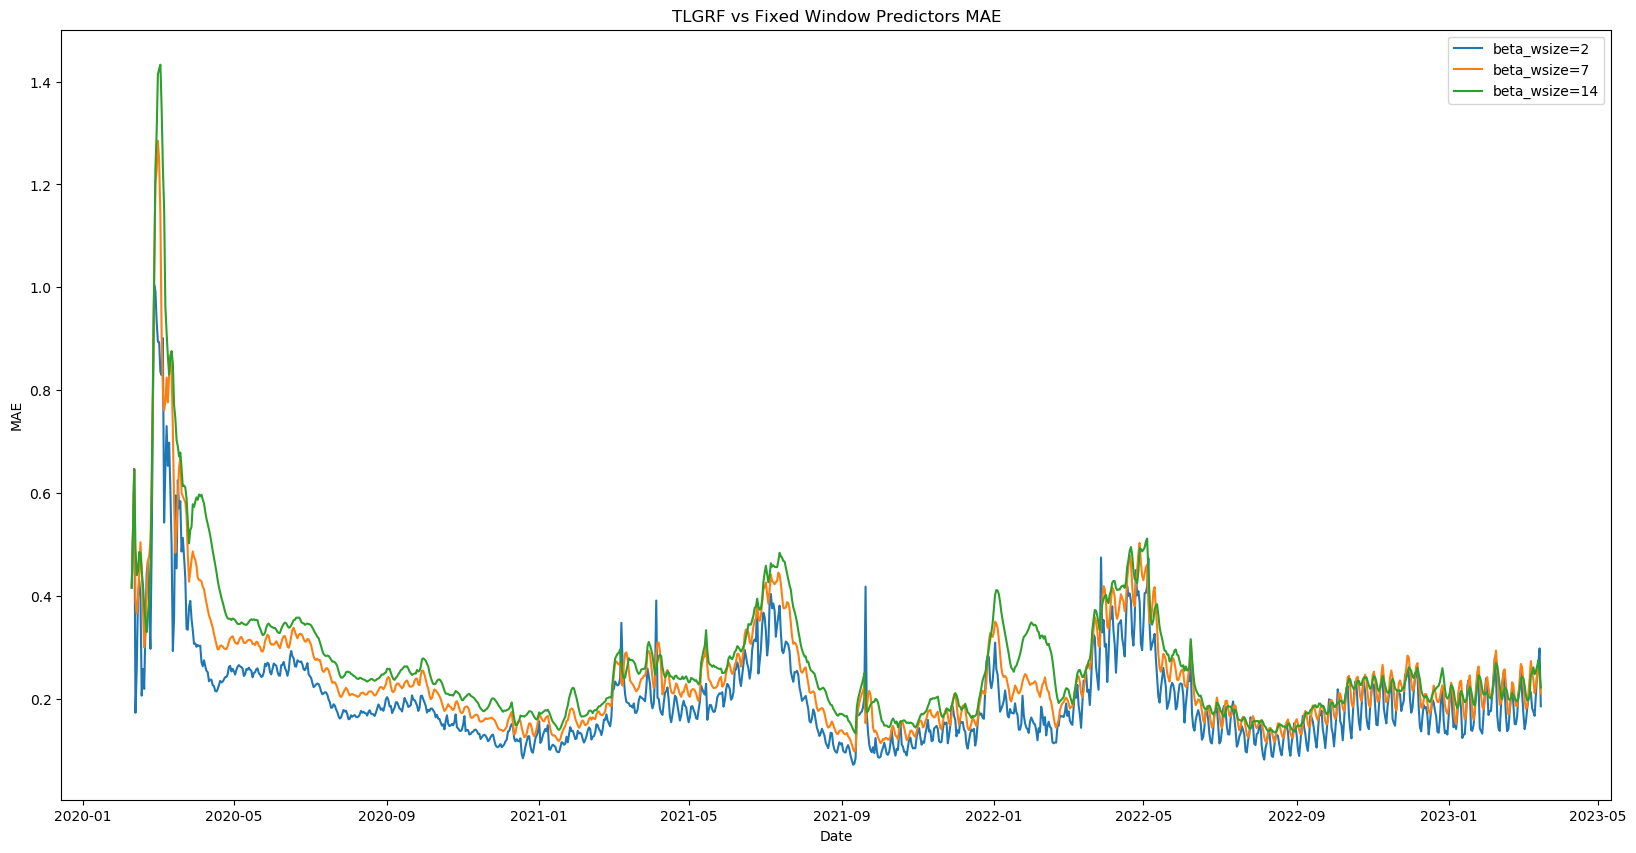

In [59]:
plt.figure(figsize=(20,10))
plot_columns =  ["beta_wsize={}".format(window_size) for window_size in [2,7,14]]
#plot_columns =  ["r_TLGRF"] + ["beta_wsize={}".format(window_size) for window_size in [2]]
for plot_column in tqdm(plot_columns):
    plt.plot(MAE_df[plot_column], label=plot_column)
plt.xlabel("Date")
plt.ylabel("MAE")
plt.title("TLGRF vs Fixed Window Predictors MAE")
plt.legend()
plt.show()

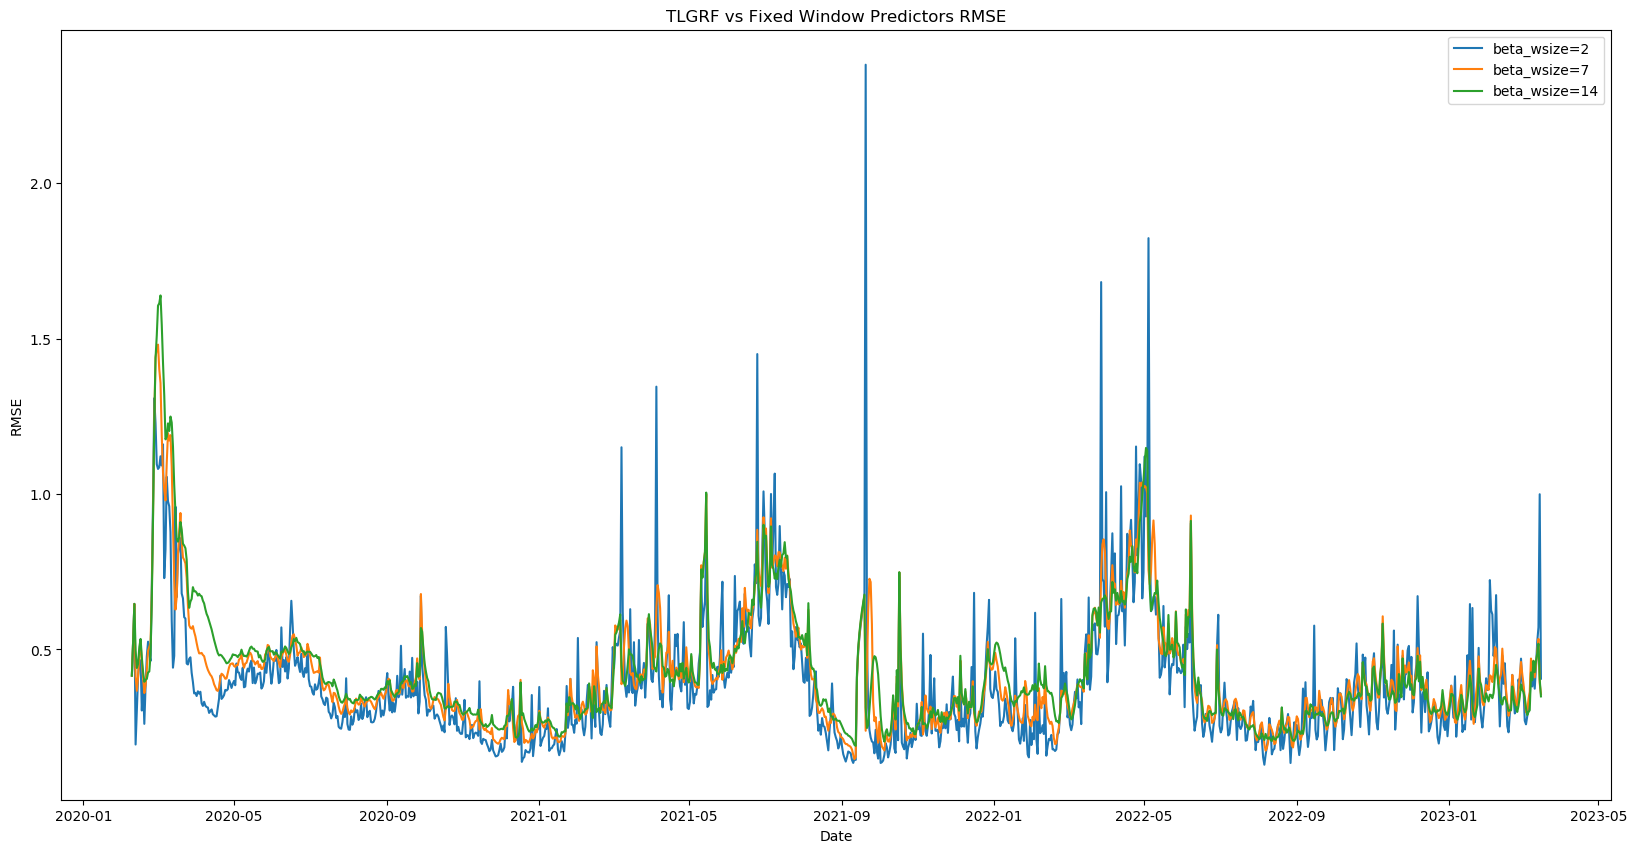

In [60]:
plt.figure(figsize=(20,10))
plot_columns = ["beta_wsize={}".format(window_size) for window_size in [2,7,14]]
#plot_columns =  ["r_TLGRF"] + ["beta_wsize={}".format(window_size) for window_size in [2]]
for plot_column in tqdm(plot_columns):
    plt.plot(RMSE_df[plot_column], label=plot_column)
plt.xlabel("Date")
plt.ylabel("RMSE")
plt.title("TLGRF vs Fixed Window Predictors RMSE")
plt.legend()
plt.show()

In [ ]:
break

In [ ]:
augmented_df = dd.read_csv("../../data/augmented_us-counties_latest.csv", assume_missing=True).compute()

In [ ]:
augmented_df = augmented_df.sort_values(by=["fips", "days_from_start"])

In [ ]:
augmented_df["date"] = pd.to_datetime(augmented_df["date"])

In [ ]:
us_counties_latest = dd.read_csv("../../data/us-counties_latest.csv", assume_missing=True).compute()

In [ ]:
us_counties_latest = us_counties_latest.sort_values(by=["fips","date"])
us_counties_latest = us_counties_latest[~us_counties_latest["fips"].isna()]
us_counties_latest["date"] = pd.to_datetime(us_counties_latest["date"])
display(us_counties_latest)

In [ ]:
# Group DataFrame by 'fips'
grouped = augmented_df.groupby('fips')

# Detect breaks in continuity for each 'fips'
for fips, group in grouped:
    diff = group['date'].diff()
    if (diff > pd.Timedelta(days=1)).any():
        print("Break in continuity detected for fips:", fips)


In [ ]:
augmented_df